In [1]:
#Se5up and imports

from google.colab import drive
drive.mount('/content/drive')

import os
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T

# Evaluation / perceptual loss libraries
!pip -q install lpips torchmetrics
import lpips
from torchmetrics.image import StructuralSimilarityIndexMeasure

# Select GPU if available, otherwise CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 63.7 MB/s eta 0:00:00
Using device: cuda
GPU: NVIDIA A100-SXM4-40GB


In [2]:
#Dataset Path and printing it

data_dir = "/content/drive/MyDrive/data"
print("Dataset folders:", os.listdir(data_dir))

Dataset folders: ['.DS_Store', 'train', 'validate', 'test']


In [4]:
# This copies your data from the slow Drive to the fast local /content/ folder
import shutil

print("🚚 Copying data to local storage (this takes a few minutes but saves hours later)...")
shutil.copytree("/content/drive/MyDrive/data", "/content/local_data", dirs_exist_ok=True)
print("✅ Done! Data is now on the local SSD.")

🚚 Copying data to local storage (this takes a few minutes but saves hours later)...


KeyboardInterrupt: 

In [3]:
#paired dataset class

class PairedImageDataset(Dataset):
    """
    Pairs compressed and ground-truth images by matching filename stems.
    Example:
        compressed: 100.jp2
        ground_truth: 100.png
    """

    def __init__(self, compressed_dir, ground_truth_dir, image_size=None, mode="RGB"):
        self.compressed_dir = Path(compressed_dir)
        self.ground_truth_dir = Path(ground_truth_dir)
        self.mode = mode

        # Collect files
        comp_files = [p for p in self.compressed_dir.iterdir() if p.is_file()]
        gt_files = [p for p in self.ground_truth_dir.iterdir() if p.is_file()]

        # Map by filename stem
        comp_map = {p.stem: p for p in comp_files}
        gt_map = {p.stem: p for p in gt_files}

        # Keep only valid matched pairs
        common_keys = sorted(set(comp_map.keys()) & set(gt_map.keys()))
        only_in_comp = sorted(set(comp_map.keys()) - set(gt_map.keys()))
        only_in_gt = sorted(set(gt_map.keys()) - set(comp_map.keys()))

        print(f"Matched pairs: {len(common_keys)}")
        print(f"Skipped (only in compressed): {len(only_in_comp)}")
        print(f"Skipped (only in ground_truth): {len(only_in_gt)}")

        self.pairs = [(comp_map[k], gt_map[k]) for k in common_keys]

        # Build transform pipeline
        transform_list = []
        if image_size is not None:
            transform_list.append(T.Resize((image_size, image_size)))
        transform_list.append(T.ToTensor())
        self.transform = T.Compose(transform_list)

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        comp_path, gt_path = self.pairs[idx]

        comp_img = Image.open(comp_path).convert(self.mode)
        gt_img = Image.open(gt_path).convert(self.mode)

        comp_img = self.transform(comp_img)
        gt_img = self.transform(gt_img)

        return comp_img, gt_img, comp_path.name, gt_path.name

In [ ]:
#Loading datset

IMAGE_SIZE = 256
MODE = "RGB"

train_dataset = PairedImageDataset(
    compressed_dir=f"{data_dir}/train/compressed",
    ground_truth_dir=f"{data_dir}/train/ground_truth",
    image_size=IMAGE_SIZE,
    mode=MODE
)

val_dataset = PairedImageDataset(
    compressed_dir=f"{data_dir}/validate/compressed",
    ground_truth_dir=f"{data_dir}/validate/ground_truth",
    image_size=IMAGE_SIZE,
    mode=MODE
)

test_dataset = PairedImageDataset(
    compressed_dir=f"{data_dir}/test/compressed",
    ground_truth_dir=f"{data_dir}/test/ground_truth",
    image_size=IMAGE_SIZE,
    mode=MODE
)

print("Train:", len(train_dataset))
print("Val:", len(val_dataset))
print("Test:", len(test_dataset))

Matched pairs: 8000
Skipped (only in compressed): 78
Skipped (only in ground_truth): 13
Matched pairs: 1000
Skipped (only in compressed): 0
Skipped (only in ground_truth): 0
Matched pairs: 1000
Skipped (only in compressed): 0
Skipped (only in ground_truth): 0
Train: 8000
Val: 1000
Test: 1000


Visualization check: One compressed image and its Ground truth


1.jp2 | 1.png


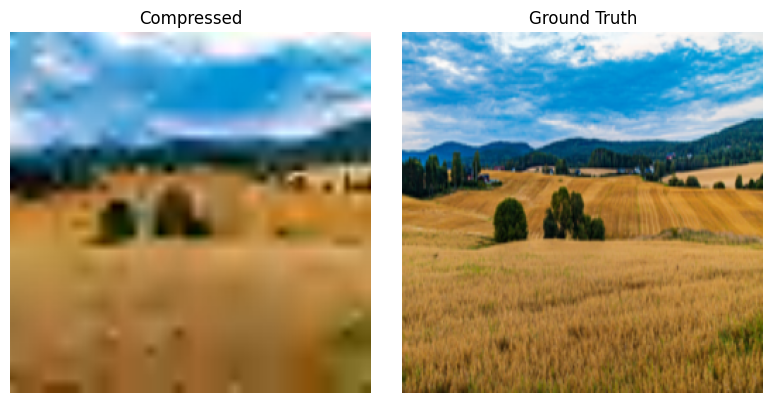

In [ ]:
#Sanity check

def show_pair(comp, gt, title1="Compressed", title2="Ground Truth"):
    comp_np = comp.permute(1, 2, 0).numpy()
    gt_np = gt.permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(np.clip(comp_np, 0, 1))
    ax[0].set_title(title1)
    ax[1].imshow(np.clip(gt_np, 0, 1))
    ax[1].set_title(title2)

    for a in ax:
        a.axis("off")
    plt.tight_layout()
    plt.show()

comp, gt, c_name, g_name = train_dataset[0]
print(c_name, "|", g_name)
show_pair(comp, gt)

Tiny subset for lab demo. Reduced training time.

In [ ]:
#Tiny subset
tiny_train_indices = list(range(64))
tiny_val_indices = list(range(16))

tiny_train_dataset = Subset(train_dataset, tiny_train_indices)
tiny_val_dataset = Subset(val_dataset, tiny_val_indices)

# Use small batch size and num_workers=0 for Colab stability
tiny_train_loader = DataLoader(tiny_train_dataset, batch_size=4, shuffle=True, num_workers=0)
tiny_val_loader = DataLoader(tiny_val_dataset, batch_size=4, shuffle=False, num_workers=0)

print("Tiny train size:", len(tiny_train_dataset))
print("Tiny val size:", len(tiny_val_dataset))

Tiny train size: 64
Tiny val size: 16


Small resnet restortaion model: This block defines a lightweight residual restoration model. Each residual block learns a refinement over its input, and the full network predicts a correction that is added back to the compressed image.

In [ ]:
#Resnet

class ResidualBlock(nn.Module):
    """
    Basic residual block:
    output = input + conv_block(input)
    """
    def __init__(self, channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, kernel_size=3, padding=1)
        )

    def forward(self, x):
        return x + self.block(x)


class SmallResNetRestoration(nn.Module):
    """
    Lightweight residual restoration network for demo purposes.
    The network predicts a correction that is added to the input image.
    """
    def __init__(self, in_channels=3, num_features=32, num_blocks=4):
        super().__init__()
        self.entry = nn.Conv2d(in_channels, num_features, kernel_size=3, padding=1)
        self.relu = nn.ReLU(inplace=True)
        self.blocks = nn.Sequential(*[ResidualBlock(num_features) for _ in range(num_blocks)])
        self.exit = nn.Conv2d(num_features, in_channels, kernel_size=3, padding=1)

    def forward(self, x):
        feat = self.relu(self.entry(x))
        feat = self.blocks(feat)
        correction = self.exit(feat)
        return x + correction

LOSS FUNCTION: Improvised loss function, with addition of LPIPS.

In [ ]:
## LOss function: dual domain loss: Spatial + Frequency and LPIPS

class DualDomainLPIPSLoss(nn.Module):
    """
    Total loss:
        L_total = alpha * L_spatial + beta * L_frequency + gamma * L_lpips

    Components:
    - L_spatial: pixel-domain MSE loss
    - L_frequency: FFT-based magnitude + phase loss
    - L_lpips: perceptual similarity loss
    """

    def __init__(self, alpha=1.0, beta=0.1, gamma=0.02, lpips_net='alex'):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma

        # Spatial-domain loss
        self.spatial_loss_fn = nn.MSELoss()

        # LPIPS perceptual loss
        self.lpips_model = lpips.LPIPS(net=lpips_net).to(device)
        self.lpips_model.eval()

    def frequency_loss(self, pred, target):
        """
        Compute frequency-domain loss using FFT magnitude and phase.
        pred, target: [B, C, H, W]
        """

        # 2D FFT per channel
        pred_fft = torch.fft.fft2(pred, norm="ortho")
        target_fft = torch.fft.fft2(target, norm="ortho")

        # Magnitude
        pred_mag = torch.abs(pred_fft)
        target_mag = torch.abs(target_fft)

        mag_loss = torch.mean((pred_mag - target_mag) ** 2)

        # Phase
        pred_phase = torch.angle(pred_fft)
        target_phase = torch.angle(target_fft)

        # Wrapped phase difference to avoid discontinuity issues
        phase_diff = torch.atan2(
            torch.sin(pred_phase - target_phase),
            torch.cos(pred_phase - target_phase)
        )
        phase_loss = torch.mean(phase_diff ** 2)

        # Combined frequency-domain loss
        freq_loss = mag_loss + phase_loss
        return freq_loss, mag_loss.detach(), phase_loss.detach()

    def forward(self, pred, target):
         #Spatial Loss
        spatial_loss = self.spatial_loss_fn(pred, target)
        #Frequency domain loss
        frequency_loss, mag_loss, phase_loss = self.frequency_loss(pred, target)
        # 3. LPIPS loss
        # LPIPS expects input in [-1, 1]
        pred_lpips = pred * 2.0 - 1.0
        target_lpips = target * 2.0 - 1.0

        # If grayscale, repeat channels to 3
        if pred_lpips.shape[1] == 1:
            pred_lpips = pred_lpips.repeat(1, 3, 1, 1)
            target_lpips = target_lpips.repeat(1, 3, 1, 1)

        lpips_loss = self.lpips_model(pred_lpips, target_lpips).mean()


        # 4. Total loss
        total_loss = (
            self.alpha * spatial_loss +
            self.beta * frequency_loss +
            self.gamma * lpips_loss
        )

        return (
            total_loss,
            spatial_loss.detach(),
            frequency_loss.detach(),
            lpips_loss.detach(),
            mag_loss.detach(),
            phase_loss.detach()
        )

This block defines the final restoration loss used in the ResNet notebook. It implements your proposed Dual-Domain Loss Function and extends it with LPIPS. The loss has three parts:

Spatial loss: ensures pixel-level similarity between restored and ground-truth images
Frequency loss: compares FFT magnitude and phase so the model learns the spectral structure of the clean image
LPIPS loss: encourages perceptual similarity and reduces overly smooth outputs

This is the most important loss block in your notebook because it matches the central idea of your project: restoration should be supervised in both the spatial and spectral domains, while also maintaining perceptual realism.

Initialise model, loss, optimiser
This block defines the final restoration loss used in the ResNet notebook. It implements your proposed Dual-Domain Loss Function and extends it with LPIPS. The loss has three parts:

Spatial loss: ensures pixel-level similarity between restored and ground-truth images
Frequency loss: compares FFT magnitude and phase so the model learns the spectral structure of the clean image
LPIPS loss: encourages perceptual similarity and reduces overly smooth outputs

This is the most important loss block in your notebook because it matches the central idea of your project: restoration should be supervised in both the spatial and spectral domains, while also maintaining perceptual realism.

In [ ]:
#INITIALIZE MODEL, LOSS, OPTIMIZER

in_channels = 3 if MODE == "RGB" else 1

lab_model = SmallResNetRestoration(in_channels=in_channels).to(device)

# Dual-domain + LPIPS loss
# alpha: spatial-domain importance
# beta : frequency-domain importance
# gamma: perceptual similarity importance
criterion = DualDomainLPIPSLoss(alpha=1.0, beta=0.1, gamma=0.05)

lab_optimizer = optim.Adam(lab_model.parameters(), lr=1e-4)

print(lab_model)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:02<00:00, 95.6MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
SmallResNetRestoration(
  (entry): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU(inplace=True)
  (blocks): Sequential(
    (0): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (1): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )
    )
    (2): ResidualBlock(
      (block): Sequential(
        (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      )


Training and validation loops:
Description:
This block updates the training and validation loops so they track:
total loss
spatial loss
frequency loss
LPIPS loss
magnitude loss
phase loss
This is helpful for the final demo because you can show that the model is not only minimizing pixel error, but also learning the correct spectral structure.

In [ ]:

#TRAINING / VALIDATION LOOPS

def train_one_epoch_verbose(model, loader, criterion, optimizer, device):
    model.train()

    running_total = 0.0
    running_spatial = 0.0
    running_frequency = 0.0
    running_lpips = 0.0
    running_mag = 0.0
    running_phase = 0.0

    for batch_idx, (compressed, ground_truth, _, _) in enumerate(loader):
        compressed = compressed.to(device)
        ground_truth = ground_truth.to(device)

        optimizer.zero_grad()
        output = model(compressed)

        total_loss, spatial_loss, frequency_loss, lpips_loss, mag_loss, phase_loss = criterion(output, ground_truth)

        total_loss.backward()
        optimizer.step()

        batch_size = compressed.size(0)
        running_total += total_loss.item() * batch_size
        running_spatial += spatial_loss.item() * batch_size
        running_frequency += frequency_loss.item() * batch_size
        running_lpips += lpips_loss.item() * batch_size
        running_mag += mag_loss.item() * batch_size
        running_phase += phase_loss.item() * batch_size

        if (batch_idx + 1) % 5 == 0:
            print(
                f"  Batch {batch_idx+1}/{len(loader)} | "
                f"Total: {total_loss.item():.6f} | "
                f"Spatial: {spatial_loss.item():.6f} | "
                f"Freq: {frequency_loss.item():.6f} | "
                f"LPIPS: {lpips_loss.item():.6f}"
            )

    n = len(loader.dataset)
    return (
        running_total / n,
        running_spatial / n,
        running_frequency / n,
        running_lpips / n,
        running_mag / n,
        running_phase / n
    )


@torch.no_grad()
def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_total = 0.0
    running_spatial = 0.0
    running_frequency = 0.0
    running_lpips = 0.0
    running_mag = 0.0
    running_phase = 0.0

    for compressed, ground_truth, _, _ in loader:
        compressed = compressed.to(device)
        ground_truth = ground_truth.to(device)

        output = model(compressed)
        total_loss, spatial_loss, frequency_loss, lpips_loss, mag_loss, phase_loss = criterion(output, ground_truth)

        batch_size = compressed.size(0)
        running_total += total_loss.item() * batch_size
        running_spatial += spatial_loss.item() * batch_size
        running_frequency += frequency_loss.item() * batch_size
        running_lpips += lpips_loss.item() * batch_size
        running_mag += mag_loss.item() * batch_size
        running_phase += phase_loss.item() * batch_size

    n = len(loader.dataset)
    return (
        running_total / n,
        running_spatial / n,
        running_frequency / n,
        running_lpips / n,
        running_mag / n,
        running_phase / n
    )

In [ ]:
#LOSS BALANCE + SCORE HELPERS

def print_loss_balance(epoch, alpha, beta, gamma, spatial, frequency, lpips_val, prefix="Train"):
    w_sp = alpha * float(spatial)
    w_fr = beta * float(frequency)
    w_lp = gamma * float(lpips_val)
    total = w_sp + w_fr + w_lp + 1e-12

    p_sp = 100.0 * w_sp / total
    p_fr = 100.0 * w_fr / total
    p_lp = 100.0 * w_lp / total

    print(
        f"{prefix} Epoch {epoch:02d} | "
        f"weighted spatial={w_sp:.6f} ({p_sp:.1f}%), "
        f"freq={w_fr:.6f} ({p_fr:.1f}%), "
        f"lpips={w_lp:.6f} ({p_lp:.1f}%)"
    )

    if p_lp > 50:
        print("  Suggestion: LPIPS is dominating, lower gamma.")
    if p_fr < 10:
        print("  Suggestion: frequency term is too small, raise beta.")
    if 20 <= p_sp <= 60 and 20 <= p_fr <= 60 and 10 <= p_lp <= 40:
        print("  Suggestion: weighted balance looks reasonable.")


def compute_psnr_tensor(pred, target, eps=1e-12):
    mse = torch.mean((pred - target) ** 2).item()
    if mse <= eps:
        return 100.0
    return 20.0 * math.log10(1.0) - 10.0 * math.log10(mse)


@torch.no_grad()
def evaluate_quick_metrics(model, loader, device):
    model.eval()
    ssim_metric_local = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    lpips_eval = lpips.LPIPS(net='alex').to(device)
    lpips_eval.eval()

    psnr_scores, ssim_scores, lpips_scores = [], [], []

    for compressed, ground_truth, _, _ in loader:
        compressed = compressed.to(device)
        ground_truth = ground_truth.to(device)
        output = model(compressed).clamp(0, 1)

        psnr_scores.append(compute_psnr_tensor(output, ground_truth))
        ssim_scores.append(ssim_metric_local(output, ground_truth).item())

        out_lpips = output * 2.0 - 1.0
        gt_lpips = ground_truth * 2.0 - 1.0
        if out_lpips.shape[1] == 1:
            out_lpips = out_lpips.repeat(1, 3, 1, 1)
            gt_lpips = gt_lpips.repeat(1, 3, 1, 1)
        lpips_scores.append(lpips_eval(out_lpips, gt_lpips).mean().item())

    return {
        "PSNR": float(np.mean(psnr_scores)),
        "SSIM": float(np.mean(ssim_scores)),
        "LPIPS": float(np.mean(lpips_scores)),
    }


def composite_score(metrics):
    # Higher is better; keep this fixed across runs.
    return metrics["PSNR"] + 20.0 * metrics["SSIM"] - 10.0 * metrics["LPIPS"]


class AdaptiveLossWeights:
    """
    Adapt beta/gamma so weighted components stay in a similar magnitude range.

    Rules:
    - If LPIPS share is too high, gamma is pushed down.
    - If frequency share is too low, beta is pushed up.
    - Smooth with EMA to avoid oscillations.
    """

    def __init__(
        self,
        enabled=True,
        warmup_epochs=2,
        ema_momentum=0.8,
        beta_bounds=(1e-4, 1.0),
        gamma_bounds=(1e-4, 1.0),
        max_step_frac=0.2,
        target_shares=(0.45, 0.30, 0.25),
    ):
        self.enabled = enabled
        self.warmup_epochs = warmup_epochs
        self.ema_momentum = ema_momentum
        self.beta_bounds = beta_bounds
        self.gamma_bounds = gamma_bounds
        self.max_step_frac = max_step_frac
        self.target_shares = target_shares
        self.ema_shares = None

    def _clip(self, x, lo, hi):
        return max(lo, min(hi, x))

    def update(self, criterion, spatial, frequency, lpips_val, epoch):
        if (not self.enabled) or epoch <= self.warmup_epochs:
            return {
                "updated": False,
                "beta": float(criterion.beta),
                "gamma": float(criterion.gamma),
                "shares": None,
            }

        eps = 1e-12
        w_sp = float(criterion.alpha) * float(spatial)
        w_fr = float(criterion.beta) * float(frequency)
        w_lp = float(criterion.gamma) * float(lpips_val)
        total = w_sp + w_fr + w_lp + eps

        shares = np.array([w_sp / total, w_fr / total, w_lp / total], dtype=np.float64)

        if self.ema_shares is None:
            self.ema_shares = shares
        else:
            self.ema_shares = (
                self.ema_momentum * self.ema_shares +
                (1.0 - self.ema_momentum) * shares
            )

        _, fr_tgt, lp_tgt = self.target_shares
        _, fr_share, lp_share = self.ema_shares

        # Base multiplicative correction toward target shares
        fr_ratio = fr_tgt / (fr_share + eps)
        lp_ratio = lp_tgt / (lp_share + eps)

        fr_ratio = self._clip(fr_ratio, 1.0 - self.max_step_frac, 1.0 + self.max_step_frac)
        lp_ratio = self._clip(lp_ratio, 1.0 - self.max_step_frac, 1.0 + self.max_step_frac)

        # Hard nudges for your two explicit conditions
        if lp_share > 0.50:
            lp_ratio = min(lp_ratio, 1.0 - 0.5 * self.max_step_frac)
        if fr_share < 0.10:
            fr_ratio = max(fr_ratio, 1.0 + 0.5 * self.max_step_frac)

        new_beta = float(criterion.beta) * fr_ratio
        new_gamma = float(criterion.gamma) * lp_ratio

        new_beta = self._clip(new_beta, self.beta_bounds[0], self.beta_bounds[1])
        new_gamma = self._clip(new_gamma, self.gamma_bounds[0], self.gamma_bounds[1])

        criterion.beta = new_beta
        criterion.gamma = new_gamma

        return {
            "updated": True,
            "beta": new_beta,
            "gamma": new_gamma,
            "shares": {
                "spatial": float(self.ema_shares[0]),
                "frequency": float(self.ema_shares[1]),
                "lpips": float(self.ema_shares[2]),
            },
        }

Training the resnet model: This block trains the ResNet model on the tiny subset for a few demo epochs and stores all loss components.

---



In [ ]:
#TRAINING THE MODEL

lab_epochs = 20
inspect_first_n_epochs = 3

# Early stopping on composite score
early_stop_patience = 4
early_stop_min_delta = 0.02
epochs_without_improvement = 0

# Programmatic balancing of beta/gamma using weighted-loss shares
adaptive_balancer = AdaptiveLossWeights(
    enabled=True,
    warmup_epochs=2,
    ema_momentum=0.8,
    beta_bounds=(1e-4, 1.0),
    gamma_bounds=(1e-4, 1.0),
    max_step_frac=0.2,
    target_shares=(0.45, 0.30, 0.25),
)

train_total_losses = []
train_spatial_losses = []
train_frequency_losses = []
train_lpips_losses = []
train_mag_losses = []
train_phase_losses = []

val_total_losses = []
val_spatial_losses = []
val_frequency_losses = []
val_lpips_losses = []
val_mag_losses = []
val_phase_losses = []

val_psnr_scores = []
val_ssim_scores = []
val_lpips_scores = []
score_history = []

beta_history = []
gamma_history = []

best_score = -float('inf')
best_epoch = -1
best_metrics = None

for epoch in range(1, lab_epochs + 1):
    print(f"\nEpoch {epoch}/{lab_epochs}")

    train_total, train_spatial, train_freq, train_lp, train_mag, train_phase = train_one_epoch_verbose(
        lab_model, tiny_train_loader, criterion, lab_optimizer, device
    )

    val_total, val_spatial, val_freq, val_lp, val_mag, val_phase = validate_one_epoch(
        lab_model, tiny_val_loader, criterion, device
    )

    # Adjust beta/gamma using current weighted-loss balance on validation components.
    adapt_info = adaptive_balancer.update(
        criterion,
        spatial=val_spatial,
        frequency=val_freq,
        lpips_val=val_lp,
        epoch=epoch,
    )

    if adapt_info["updated"]:
        s = adapt_info["shares"]
        print(
            "  Adaptive weights -> "
            f"beta={adapt_info['beta']:.6f}, gamma={adapt_info['gamma']:.6f} | "
            f"EMA shares: spatial={100*s['spatial']:.1f}%, "
            f"freq={100*s['frequency']:.1f}%, lpips={100*s['lpips']:.1f}%"
        )

    beta_history.append(float(criterion.beta))
    gamma_history.append(float(criterion.gamma))

    train_total_losses.append(train_total)
    train_spatial_losses.append(train_spatial)
    train_frequency_losses.append(train_freq)
    train_lpips_losses.append(train_lp)
    train_mag_losses.append(train_mag)
    train_phase_losses.append(train_phase)

    val_total_losses.append(val_total)
    val_spatial_losses.append(val_spatial)
    val_frequency_losses.append(val_freq)
    val_lpips_losses.append(val_lp)
    val_mag_losses.append(val_mag)
    val_phase_losses.append(val_phase)

    if epoch <= inspect_first_n_epochs:
        print_loss_balance(epoch, criterion.alpha, criterion.beta, criterion.gamma, train_spatial, train_freq, train_lp, prefix="Train")
        print_loss_balance(epoch, criterion.alpha, criterion.beta, criterion.gamma, val_spatial, val_freq, val_lp, prefix="Val")

    epoch_metrics = evaluate_quick_metrics(lab_model, tiny_val_loader, device)
    epoch_score = composite_score(epoch_metrics)

    val_psnr_scores.append(epoch_metrics["PSNR"])
    val_ssim_scores.append(epoch_metrics["SSIM"])
    val_lpips_scores.append(epoch_metrics["LPIPS"])
    score_history.append(epoch_score)

    print(
        f"Epoch {epoch}/{lab_epochs} | "
        f"Train Total: {train_total:.6f}, Spatial: {train_spatial:.6f}, Freq: {train_freq:.6f}, LPIPS: {train_lp:.6f} | "
        f"Val Total: {val_total:.6f}, Spatial: {val_spatial:.6f}, Freq: {val_freq:.6f}, LPIPS: {val_lp:.6f}"
    )
    print(
        f"Val metrics -> PSNR: {epoch_metrics['PSNR']:.3f}, "
        f"SSIM: {epoch_metrics['SSIM']:.4f}, "
        f"LPIPS: {epoch_metrics['LPIPS']:.4f}, "
        f"Score: {epoch_score:.4f}"
    )

    if epoch_score > (best_score + early_stop_min_delta):
        best_score = epoch_score
        best_epoch = epoch
        best_metrics = epoch_metrics
        epochs_without_improvement = 0
        torch.save(lab_model.state_dict(), "/content/drive/MyDrive/best_small_resnet_by_score.pth")
        print("  New best checkpoint saved: /content/drive/MyDrive/best_small_resnet_by_score.pth")
    else:
        epochs_without_improvement += 1
        print(
            f"  No significant score improvement "
            f"({epochs_without_improvement}/{early_stop_patience})"
        )

    if epochs_without_improvement >= early_stop_patience:
        print(
            f"\nEarly stopping triggered at epoch {epoch}. "
            f"Best epoch was {best_epoch} with score {best_score:.4f}."
        )
        break

print("\nBest epoch:", best_epoch)
print("Best score:", best_score)
print("Best metrics:", best_metrics)
print(
    f"Best score params -> alpha={criterion.alpha}, "
    f"beta={criterion.beta}, gamma={criterion.gamma}"
)

if beta_history and gamma_history:
    print(f"Final adaptive beta={beta_history[-1]:.6f}, gamma={gamma_history[-1]:.6f}")


Epoch 1/5
  Batch 5/16 | Total: 0.303165 | Spatial: 0.012990 | Freq: 2.624528 | LPIPS: 0.554435
  Batch 10/16 | Total: 0.302383 | Spatial: 0.009221 | Freq: 2.698024 | LPIPS: 0.467182
  Batch 15/16 | Total: 0.287723 | Spatial: 0.007048 | Freq: 2.578564 | LPIPS: 0.456367
Epoch 1/5 | Train Total: 0.302897, Spatial: 0.012649, Freq: 2.644977, LPIPS: 0.515019 | Val Total: 0.291146, Spatial: 0.007363, Freq: 2.603436, LPIPS: 0.468783

Epoch 2/5
  Batch 5/16 | Total: 0.295691 | Spatial: 0.010021 | Freq: 2.609406 | LPIPS: 0.494594
  Batch 10/16 | Total: 0.308043 | Spatial: 0.006833 | Freq: 2.766451 | LPIPS: 0.491294
  Batch 15/16 | Total: 0.303211 | Spatial: 0.006439 | Freq: 2.730774 | LPIPS: 0.473896
Epoch 2/5 | Train Total: 0.293284, Spatial: 0.006433, Freq: 2.635075, LPIPS: 0.466883 | Val Total: 0.287128, Spatial: 0.005780, Freq: 2.599112, LPIPS: 0.428742

Epoch 3/5
  Batch 5/16 | Total: 0.292599 | Spatial: 0.005230 | Freq: 2.644213 | LPIPS: 0.458957
  Batch 10/16 | Total: 0.308762 | Spatial

In [3]:
# AUTO SWEEP: alpha / beta / gamma on tiny subset

sweep_configs = [
    {"alpha": 1.0, "beta": 0.0, "gamma": 0.0},
    {"alpha": 0.0, "beta": 1.0, "gamma": 0.0},
    {"alpha": 0.0, "beta": 0.0, "gamma": 1.0},
    {"alpha": 0.33, "beta": 0.33, "gamma": 0.33},
    {"alpha": 1.0, "beta": 0.03, "gamma": 0.01},
    {"alpha": 1.0, "beta": 0.05, "gamma": 0.01},
    {"alpha": 1.0, "beta": 0.05, "gamma": 0.02},
]

sweep_epochs = 20
sweep_patience = 4
sweep_min_delta = 0.02
sweep_lr = 1e-4

sweep_results = []

for run_idx, cfg in enumerate(sweep_configs, start=1):
    print("\n" + "=" * 80)
    print(
        f"Sweep run {run_idx}/{len(sweep_configs)} | "
        f"alpha={cfg['alpha']}, beta={cfg['beta']}, gamma={cfg['gamma']}"
    )

    # Fresh model + loss + optimizer per config for a fair comparison
    run_model = SmallResNetRestoration(in_channels=in_channels).to(device)
    run_criterion = DualDomainLPIPSLoss(
        alpha=cfg["alpha"],
        beta=cfg["beta"],
        gamma=cfg["gamma"],
    )
    run_optimizer = optim.Adam(run_model.parameters(), lr=sweep_lr)

    best_score = -float("inf")
    best_epoch = -1
    best_metrics = None
    epochs_without_improvement = 0

    for epoch in range(1, sweep_epochs + 1):
        train_total, train_spatial, train_freq, train_lp, train_mag, train_phase = train_one_epoch_verbose(
            run_model, tiny_train_loader, run_criterion, run_optimizer, device
        )

        val_total, val_spatial, val_freq, val_lp, val_mag, val_phase = validate_one_epoch(
            run_model, tiny_val_loader, run_criterion, device
        )

        epoch_metrics = evaluate_quick_metrics(run_model, tiny_val_loader, device)
        epoch_score = composite_score(epoch_metrics)

        print(
            f"  Epoch {epoch:02d} | "
            f"Train Total={train_total:.4f} | "
            f"Val Total={val_total:.4f} | "
            f"Score={epoch_score:.4f}"
        )

        if epoch_score > (best_score + sweep_min_delta):
            best_score = epoch_score
            best_epoch = epoch
            best_metrics = epoch_metrics
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= sweep_patience:
            print(
                f"  Early stopping at epoch {epoch} "
                f"(best epoch {best_epoch}, best score {best_score:.4f})"
            )
            break

    sweep_results.append(
        {
            "alpha": cfg["alpha"],
            "beta": cfg["beta"],
            "gamma": cfg["gamma"],
            "best_epoch": best_epoch,
            "best_score": float(best_score),
            "best_metrics": best_metrics,
        }
    )

print("\n" + "=" * 80)
print("SWEEP SUMMARY (sorted by best_score):")

sweep_results_sorted = sorted(sweep_results, key=lambda x: x["best_score"], reverse=True)
for i, r in enumerate(sweep_results_sorted, start=1):
    m = r["best_metrics"]
    print(
        f"{i:02d}. alpha={r['alpha']}, beta={r['beta']}, gamma={r['gamma']} | "
        f"best_epoch={r['best_epoch']} | best_score={r['best_score']:.4f} | "
        f"PSNR={m['PSNR']:.3f}, SSIM={m['SSIM']:.4f}, LPIPS={m['LPIPS']:.4f}"
    )

# Optional: set the top config as the notebook's active criterion for next training cells
best_cfg = sweep_results_sorted[0]
print("\nTop config from sweep:")
print(
    f"alpha={best_cfg['alpha']}, beta={best_cfg['beta']}, gamma={best_cfg['gamma']} "
    f"(score={best_cfg['best_score']:.4f})"
)

criterion = DualDomainLPIPSLoss(
    alpha=best_cfg["alpha"],
    beta=best_cfg["beta"],
    gamma=best_cfg["gamma"],
)
print("Updated criterion to top config for follow-up training.")


Sweep run 1/7 | alpha=1.0, beta=0.0, gamma=0.0


NameError: name 'SmallResNetRestoration' is not defined

In [ ]:
# CONFIRMATION RUN ON FULL TRAIN/VAL + FINAL TEST EVAL
# Uses the top sweep config already assigned to `criterion`.

# Safer loaders for full data in Colab
full_train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
full_val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0)
full_test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0)

# Reinitialize model/optimizer for a clean full-data run
full_model = SmallResNetRestoration(in_channels=in_channels).to(device)
full_optimizer = optim.Adam(full_model.parameters(), lr=1e-4)

full_epochs = 20
full_patience = 4
full_min_delta = 0.02
full_epochs_without_improvement = 0

full_best_score = -float("inf")
full_best_epoch = -1
full_best_metrics = None
full_best_path = "/content/drive/MyDrive/best_small_resnet_full_by_score.pth"

for epoch in range(1, full_epochs + 1):
    print(f"\n[Full] Epoch {epoch}/{full_epochs}")

    train_total, train_spatial, train_freq, train_lp, train_mag, train_phase = train_one_epoch_verbose(
        full_model, full_train_loader, criterion, full_optimizer, device
    )

    val_total, val_spatial, val_freq, val_lp, val_mag, val_phase = validate_one_epoch(
        full_model, full_val_loader, criterion, device
    )

    val_metrics = evaluate_quick_metrics(full_model, full_val_loader, device)
    val_score = composite_score(val_metrics)

    print(
        f"[Full] Train Total: {train_total:.6f} | Val Total: {val_total:.6f} | "
        f"Val PSNR: {val_metrics['PSNR']:.3f}, SSIM: {val_metrics['SSIM']:.4f}, "
        f"LPIPS: {val_metrics['LPIPS']:.4f}, Score: {val_score:.4f}"
    )

    if val_score > (full_best_score + full_min_delta):
        full_best_score = val_score
        full_best_epoch = epoch
        full_best_metrics = val_metrics
        full_epochs_without_improvement = 0
        torch.save(full_model.state_dict(), full_best_path)
        print(f"[Full] New best checkpoint saved: {full_best_path}")
    else:
        full_epochs_without_improvement += 1
        print(f"[Full] No significant improvement ({full_epochs_without_improvement}/{full_patience})")

    if full_epochs_without_improvement >= full_patience:
        print(
            f"\n[Full] Early stopping at epoch {epoch}. "
            f"Best epoch: {full_best_epoch}, best score: {full_best_score:.4f}"
        )
        break

print("\n[Full] Best validation epoch:", full_best_epoch)
print("[Full] Best validation score:", full_best_score)
print("[Full] Best validation metrics:", full_best_metrics)
print(
    f"[Full] Params -> alpha={criterion.alpha}, beta={criterion.beta}, gamma={criterion.gamma}"
)

# Final test evaluation using best full-data checkpoint
full_model.load_state_dict(torch.load(full_best_path, map_location=device))

# Local fallback evaluator so this cell does not depend on later notebook cells.
@torch.no_grad()
def evaluate_model_local(model, loader, device):
    model.eval()

    ssim_metric_local = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    lpips_eval = lpips.LPIPS(net='alex').to(device)
    lpips_eval.eval()

    mse_scores = []
    psnr_scores = []
    ssim_scores = []
    lpips_scores = []

    for compressed, ground_truth, _, _ in loader:
        compressed = compressed.to(device)
        ground_truth = ground_truth.to(device)

        output = model(compressed).clamp(0, 1)

        mse = torch.mean((output - ground_truth) ** 2).item()
        psnr = compute_psnr_tensor(output, ground_truth)
        ssim = ssim_metric_local(output, ground_truth).item()

        out_lpips = output * 2.0 - 1.0
        gt_lpips = ground_truth * 2.0 - 1.0
        if out_lpips.shape[1] == 1:
            out_lpips = out_lpips.repeat(1, 3, 1, 1)
            gt_lpips = gt_lpips.repeat(1, 3, 1, 1)

        lpips_val = lpips_eval(out_lpips, gt_lpips).mean().item()

        mse_scores.append(mse)
        psnr_scores.append(psnr)
        ssim_scores.append(ssim)
        lpips_scores.append(lpips_val)

    return {
        "MSE": float(np.mean(mse_scores)),
        "PSNR": float(np.mean(psnr_scores)),
        "SSIM": float(np.mean(ssim_scores)),
        "LPIPS": float(np.mean(lpips_scores)),
    }

test_results = evaluate_model_local(full_model, full_test_loader, device)
print("\n[TEST] Final results:", test_results)

# Save a compact report dictionary for easy copy into your write-up
final_report = {
    "config": {
        "alpha": float(criterion.alpha),
        "beta": float(criterion.beta),
        "gamma": float(criterion.gamma),
    },
    "best_val_epoch": int(full_best_epoch),
    "best_val_score": float(full_best_score),
    "best_val_metrics": full_best_metrics,
    "test_metrics": test_results,
    "best_checkpoint": full_best_path,
}

print("\nFinal report dictionary:")
print(final_report)

In [ ]:
# FAST RECOVERY: EVALUATE FROM A SAVED BEST CHECKPOINT (NO RETRAIN)

recover_ckpt_path = "/content/drive/MyDrive/best_small_resnet_full_by_score.pth"

if not os.path.exists(recover_ckpt_path):
    raise FileNotFoundError(
        f"Checkpoint not found at {recover_ckpt_path}. "
        "Set recover_ckpt_path to an existing .pth file."
    )

# Build loaders (quick to construct)
recover_val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0)
recover_test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0)

# Recreate model and load weights
recover_model = SmallResNetRestoration(in_channels=in_channels).to(device)
recover_model.load_state_dict(torch.load(recover_ckpt_path, map_location=device))
recover_model.eval()

@torch.no_grad()
def evaluate_from_checkpoint(model, loader, device):
    ssim_metric_local = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)
    lpips_eval = lpips.LPIPS(net='alex').to(device)
    lpips_eval.eval()

    mse_scores = []
    psnr_scores = []
    ssim_scores = []
    lpips_scores = []

    for compressed, ground_truth, _, _ in loader:
        compressed = compressed.to(device)
        ground_truth = ground_truth.to(device)
        output = model(compressed).clamp(0, 1)

        mse_scores.append(torch.mean((output - ground_truth) ** 2).item())
        psnr_scores.append(compute_psnr_tensor(output, ground_truth))
        ssim_scores.append(ssim_metric_local(output, ground_truth).item())

        out_lpips = output * 2.0 - 1.0
        gt_lpips = ground_truth * 2.0 - 1.0
        if out_lpips.shape[1] == 1:
            out_lpips = out_lpips.repeat(1, 3, 1, 1)
            gt_lpips = gt_lpips.repeat(1, 3, 1, 1)

        lpips_scores.append(lpips_eval(out_lpips, gt_lpips).mean().item())

    metrics = {
        "MSE": float(np.mean(mse_scores)),
        "PSNR": float(np.mean(psnr_scores)),
        "SSIM": float(np.mean(ssim_scores)),
        "LPIPS": float(np.mean(lpips_scores)),
    }
    score = metrics["PSNR"] + 20.0 * metrics["SSIM"] - 10.0 * metrics["LPIPS"]
    return metrics, float(score)

recover_val_metrics, recover_val_score = evaluate_from_checkpoint(recover_model, recover_val_loader, device)
recover_test_metrics, recover_test_score = evaluate_from_checkpoint(recover_model, recover_test_loader, device)

print("Recovered checkpoint:", recover_ckpt_path)
print("[RECOVERED VAL]", recover_val_metrics, "| score:", round(recover_val_score, 4))
print("[RECOVERED TEST]", recover_test_metrics, "| score:", round(recover_test_score, 4))

PLOTTING LOSS curves:

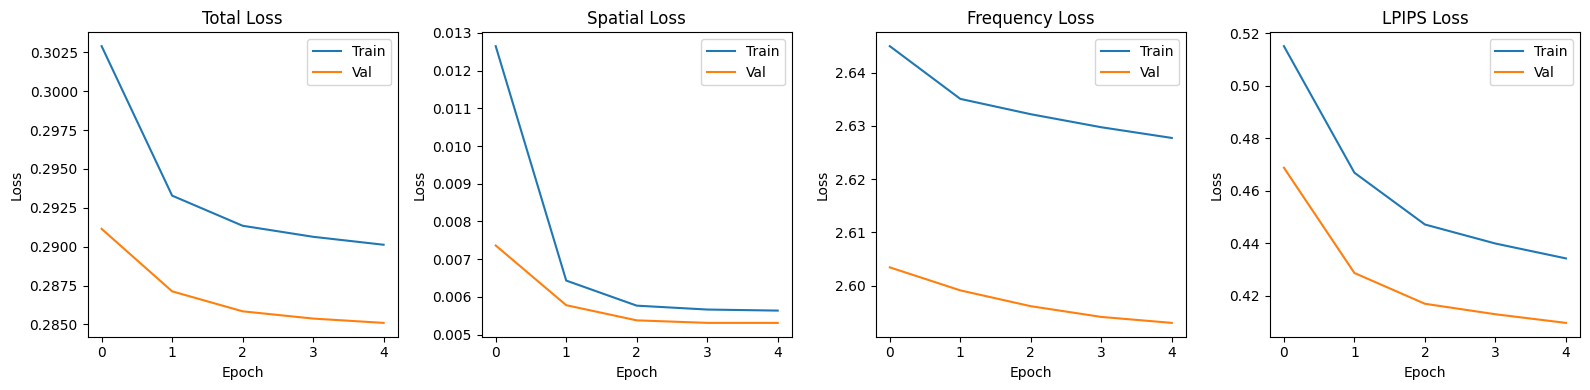

In [ ]:

# 12. PLOT LOSS CURVES

plt.figure(figsize=(16, 4))

plt.subplot(1, 4, 1)
plt.plot(train_total_losses, label="Train")
plt.plot(val_total_losses, label="Val")
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 4, 2)
plt.plot(train_spatial_losses, label="Train")
plt.plot(val_spatial_losses, label="Val")
plt.title("Spatial Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 4, 3)
plt.plot(train_frequency_losses, label="Train")
plt.plot(val_frequency_losses, label="Val")
plt.title("Frequency Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 4, 4)
plt.plot(train_lpips_losses, label="Train")
plt.plot(val_lpips_losses, label="Val")
plt.title("LPIPS Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

Visualisation function for the loss curves

In [ ]:

# 13. VISUALIZATION FUNCTION

@torch.no_grad()
def show_model_result(model, dataset, idx, title="Small ResNet Output"):
    model.eval()

    compressed, ground_truth, comp_name, gt_name = dataset[idx]
    inp = compressed.unsqueeze(0).to(device)
    output = model(inp).squeeze(0).cpu().clamp(0, 1)

    comp_np = compressed.permute(1, 2, 0).numpy()
    out_np = output.permute(1, 2, 0).numpy()
    gt_np = ground_truth.permute(1, 2, 0).numpy()

    if comp_np.shape[2] == 1:
        comp_np = comp_np.squeeze(-1)
        out_np = out_np.squeeze(-1)
        gt_np = gt_np.squeeze(-1)
        cmap = "gray"
    else:
        cmap = None

    print(comp_name, "|", gt_name)

    fig, ax = plt.subplots(1, 3, figsize=(14, 4))
    ax[0].imshow(np.clip(comp_np, 0, 1), cmap=cmap)
    ax[0].set_title("Compressed")
    ax[1].imshow(np.clip(out_np, 0, 1), cmap=cmap)
    ax[1].set_title(title)
    ax[2].imshow(np.clip(gt_np, 0, 1), cmap=cmap)
    ax[2].set_title("Ground Truth")

    for a in ax:
        a.axis("off")

    plt.tight_layout()
    plt.show()

A few reconstructions to show examples of resnet reconructions

1.jp2 | 1.png


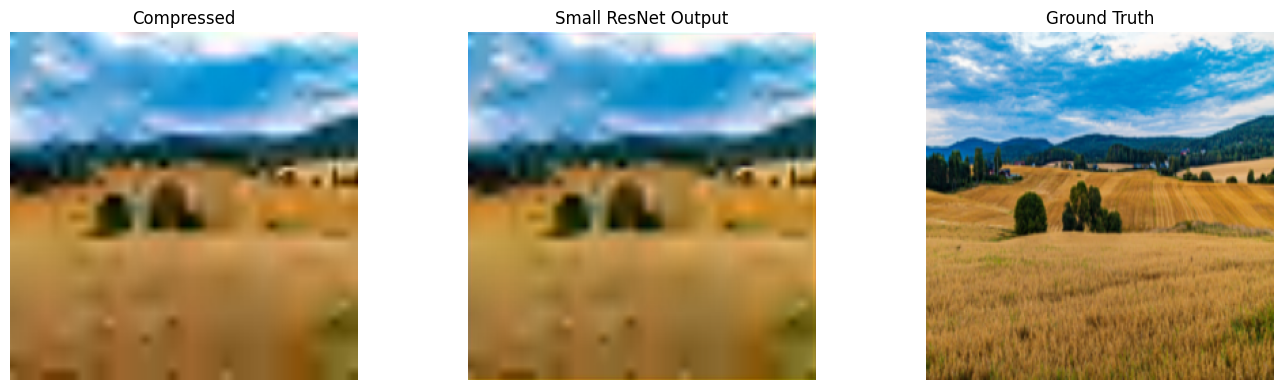

10.jp2 | 10.png


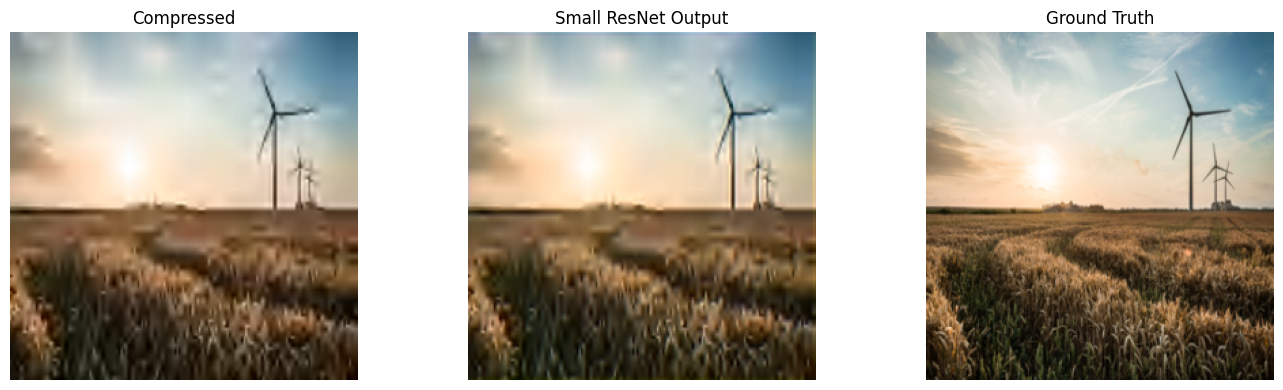

100.jp2 | 100.png


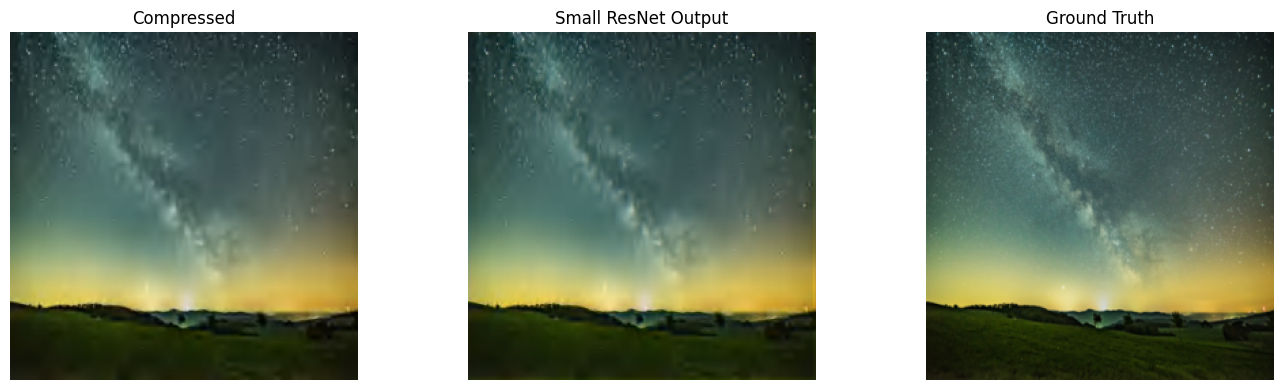

In [ ]:

#FEW RECONSTRUCTIONS

show_model_result(lab_model, train_dataset, 0)
show_model_result(lab_model, train_dataset, 1)
show_model_result(lab_model, train_dataset, 2)

Final evaluation metrics:MSE,PSNR,SSIM, LPIPS on validation set:

In [ ]:

#FINAL EVALUATION

ssim_metric = StructuralSimilarityIndexMeasure(data_range=1.0).to(device)

def compute_psnr(pred, target, max_val=1.0):
    mse = torch.mean((pred - target) ** 2).item()
    if mse == 0:
        return float("inf")
    return 20 * math.log10(max_val) - 10 * math.log10(mse)

@torch.no_grad()
def evaluate_model(model, loader, device):
    model.eval()

    mse_scores = []
    psnr_scores = []
    ssim_scores = []
    lpips_scores = []

    lpips_eval = lpips.LPIPS(net='alex').to(device)
    lpips_eval.eval()

    for compressed, ground_truth, _, _ in loader:
        compressed = compressed.to(device)
        ground_truth = ground_truth.to(device)

        output = model(compressed).clamp(0, 1)

        mse = torch.mean((output - ground_truth) ** 2).item()
        psnr = compute_psnr(output, ground_truth)
        ssim = ssim_metric(output, ground_truth).item()

        out_lpips = output * 2.0 - 1.0
        gt_lpips = ground_truth * 2.0 - 1.0
        if out_lpips.shape[1] == 1:
            out_lpips = out_lpips.repeat(1, 3, 1, 1)
            gt_lpips = gt_lpips.repeat(1, 3, 1, 1)

        lpips_val = lpips_eval(out_lpips, gt_lpips).mean().item()

        mse_scores.append(mse)
        psnr_scores.append(psnr)
        ssim_scores.append(ssim)
        lpips_scores.append(lpips_val)

    return {
        "MSE": float(np.mean(mse_scores)),
        "PSNR": float(np.mean(psnr_scores)),
        "SSIM": float(np.mean(ssim_scores)),
        "LPIPS": float(np.mean(lpips_scores))
    }

results = evaluate_model(lab_model, tiny_val_loader, device)
print("Validation results:", results)

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Validation results: {'MSE': 0.005292164976708591, 'PSNR': 22.82471172191581, 'SSIM': 0.6211839616298676, 'LPIPS': 0.40912292897701263}


Baseline model compared to RESNET model. PSNR comparison

In [ ]:

#BASELINE VS MODEL PSNR
@torch.no_grad()
def compare_baseline_vs_model(model, dataset, indices):
    model.eval()
    results = []

    for idx in indices:
        compressed, ground_truth, comp_name, _ = dataset[idx]

        inp = compressed.unsqueeze(0).to(device)
        gt = ground_truth.unsqueeze(0).to(device)
        output = model(inp).clamp(0, 1)

        psnr_compressed = compute_psnr(inp, gt)
        psnr_output = compute_psnr(output, gt)

        results.append((idx, comp_name, psnr_compressed, psnr_output))

    return results

psnr_results = compare_baseline_vs_model(lab_model, train_dataset, [0, 1, 2, 3, 4])

for r in psnr_results:
    print(
        f"Index {r[0]} | {r[1]} | "
        f"Compressed PSNR: {r[2]:.3f} | "
        f"Model PSNR: {r[3]:.3f}"
    )

Index 0 | 1.jp2 | Compressed PSNR: 22.357 | Model PSNR: 22.275
Index 1 | 10.jp2 | Compressed PSNR: 25.903 | Model PSNR: 25.613
Index 2 | 100.jp2 | Compressed PSNR: 33.519 | Model PSNR: 32.426
Index 3 | 1000.jp2 | Compressed PSNR: 22.638 | Model PSNR: 22.437
Index 4 | 1001.jp2 | Compressed PSNR: 27.583 | Model PSNR: 27.339


SAVING THIS MODEL AND OUTPUT FOR DOCUMENTATION

In [ ]:
# SAVE MODEL AND OUTPUTS

torch.save(lab_model.state_dict(), "/content/drive/MyDrive/small_resnet_dualdomain_lpips_demo.pth")
print("Model saved")

output_dir = Path("/content/drive/MyDrive/small_resnet_dualdomain_lpips_outputs")
output_dir.mkdir(parents=True, exist_ok=True)
to_pil = T.ToPILImage()

@torch.no_grad()
def save_sample_outputs(model, dataset, indices, output_dir, suffix="small_resnet_demo"):
    model.eval()
    for idx in indices:
        compressed, ground_truth, _, _ = dataset[idx]
        output = model(compressed.unsqueeze(0).to(device)).squeeze(0).cpu().clamp(0, 1)

        to_pil(compressed).save(output_dir / f"{idx}_compressed.png")
        to_pil(output).save(output_dir / f"{idx}_{suffix}.png")
        to_pil(ground_truth).save(output_dir / f"{idx}_groundtruth.png")

save_sample_outputs(lab_model, train_dataset, [0, 1, 2], output_dir)
print("Outputs saved to:", output_dir)

Model saved
Outputs saved to: /content/drive/MyDrive/small_resnet_dualdomain_lpips_outputs
